           PORTFOLIO ANALYSIS OVERVIEW            
• Total Active Portfolios Monitored : 1000 records
• System-wide Missing Data Cells    : 0
• Healthy Risk Profiles (Class 1)   : 700 (70.00%)
• Defaulted Risk Profiles (Class 2) : 300 (30.00%)

--- Structural Portfolio Quantiles (INR) ---
• Average Outflow Commitment Amount : ₹915.91
• Minimum Micro-Loan Limit Recorded : ₹56.00
• Peak Credit Concentration Risk   : ₹5,152.00
• Mean Principal Debtor Longevity   : 35.5 Years


C:\Users\Mayuresh Krishnan\AppData\Local\Temp\ipykernel_25036\2016660525.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Healthy Profile (1)', 'Default/NPA Realized (2)'])


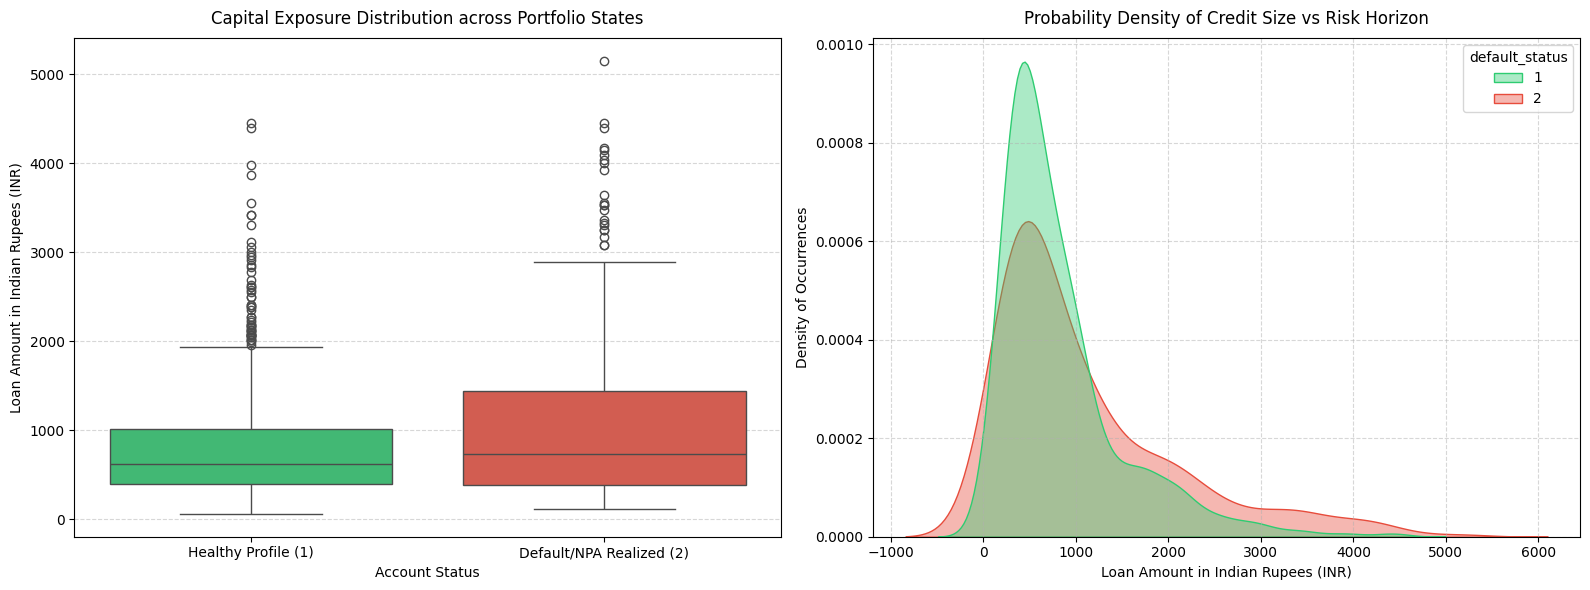

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pull the structured source directly from the repository vault
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric"
raw_df = pd.read_csv(data_url, sep=r'\s+', header=None)

# 2. Dynamic Structural Analysis (Locating columns based on true data scale profiles)
credit_col_idx = raw_df.max().idxmax()
target_col_idx = 24 # The final column index in a 0-indexed 25 column matrix

# 3. Assemble the clean operational DataFrame
processed_df = pd.DataFrame()
processed_df['duration_months'] = raw_df[1].astype(int)
processed_df['credit_amount_DM'] = raw_df[credit_col_idx].astype(float)
processed_df['age_years'] = raw_df[9].astype(int)
processed_df['default_status'] = raw_df[target_col_idx].astype(int)

# Apply context adaptation: Convert historical Deutsche Marks to INR (1 DM = Rs.28)
processed_df['loan_amount_INR'] = processed_df['credit_amount_DM'] * 28

# 4. Compile the Baseline Ledger Analytics
print("==================================================")
print("           PORTFOLIO ANALYSIS OVERVIEW            ")
print("==================================================")
print(f"• Total Active Portfolios Monitored : {processed_df.shape[0]} records")
print(f"• System-wide Missing Data Cells    : {processed_df.isnull().sum().sum()}")

# Calculate portfolio class distribution
counts = processed_df['default_status'].value_counts()
pcts = processed_df['default_status'].value_counts(normalize=True) * 100
print(f"• Healthy Risk Profiles (Class 1)   : {counts[1]} ({pcts[1]:.2f}%)")
print(f"• Defaulted Risk Profiles (Class 2) : {counts[2]} ({pcts[2]:.2f}%)")

print("\n--- Structural Portfolio Quantiles (INR) ---")
print(f"• Average Outflow Commitment Amount : ₹{processed_df['loan_amount_INR'].mean():,.2f}")
print(f"• Minimum Micro-Loan Limit Recorded : ₹{processed_df['loan_amount_INR'].min():,.2f}")
print(f"• Peak Credit Concentration Risk   : ₹{processed_df['loan_amount_INR'].max():,.2f}")
print(f"• Mean Principal Debtor Longevity   : {processed_df['age_years'].mean():.1f} Years")
print("==================================================")

# 5. Render explicit visual distribution mapping
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Boxplot visualization to spot outlier concentration windows
sns.boxplot(
    data=processed_df, 
    x='default_status', 
    y='loan_amount_INR', 
    hue='default_status',
    palette={1: '#2ecc71', 2: '#e74c3c'},
    legend=False,
    ax=ax1
)
ax1.set_title("Capital Exposure Distribution across Portfolio States", fontsize=12, pad=10)
ax1.set_xticklabels(['Healthy Profile (1)', 'Default/NPA Realized (2)'])
ax1.set_ylabel("Loan Amount in Indian Rupees (INR)")
ax1.set_xlabel("Account Status")
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Subplot B: Density distributions to watch capital risk shifts
sns.kdeplot(
    data=processed_df,
    x='loan_amount_INR',
    hue='default_status',
    fill=True,
    palette={1: '#2ecc71', 2: '#e74c3c'},
    common_norm=False,
    alpha=0.4,
    ax=ax2
)
ax2.set_title("Probability Density of Credit Size vs Risk Horizon", fontsize=12, pad=10)
ax2.set_xlabel("Loan Amount in Indian Rupees (INR)")
ax2.set_ylabel("Density of Occurrences")
ax2.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()